In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
-클러스터(cluster) : 독립변수의특성이유사한데이터의그룹
-클러스터링(clustering) : 주어진데이터를여러개의클러스터로구분하는것
1) 중심기반클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-density-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반클러스터링(DBSCAN의변형으로OPTICS) : https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = '1' 
# sklear의 로직들이 멀티스레드로 운영이 되는데, 단일 스레드로 변환함. sklearn 입포트 전에 실행

In [4]:
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format='retina'  
#한글설정
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False)  # 축의 - 깨짐 방지

# 2절. K-means 클러스터링
- 거리중점으로 가장 단순하고 빠른 클러스터링 알고리즘, 가장 많이 쓰인다.
- 클러스터의 중심을 찾아가는 알고리즘, 교안 6p

In [13]:
# 분류를 위한 가상의 데이터 생성
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100,    # 만들려는 데이터 갯수(기본값 100) 100행
                           n_features=2,   # 독립변수 개수(기본값 20)
                           n_informative=2 , # 종속변수에 영향을 미치는 독립변수 개수
                           n_redundant=0,  # 종속변수에 영향을 미치는 독리변수 개수(인포머티브 쓰면 꼭 필요)
                           n_classes=2,  # 종속변수의 그룹 수
                           n_clusters_per_class=1,  # 각 종속변수 그룹별 서브 그룹수 (-> 서브그룹수가 1이라는 건 없다는 의미) 
                           random_state=123)
import numpy as np
np.c_[X,y][:5]


array([[ 0.31968135,  1.11482094,  0.        ],
       [-1.08712913,  0.63887329,  1.        ],
       [ 2.15276789,  1.12586026,  0.        ],
       [-0.33450646, -3.07115329,  1.        ],
       [ 1.03464777,  1.06364811,  0.        ]])

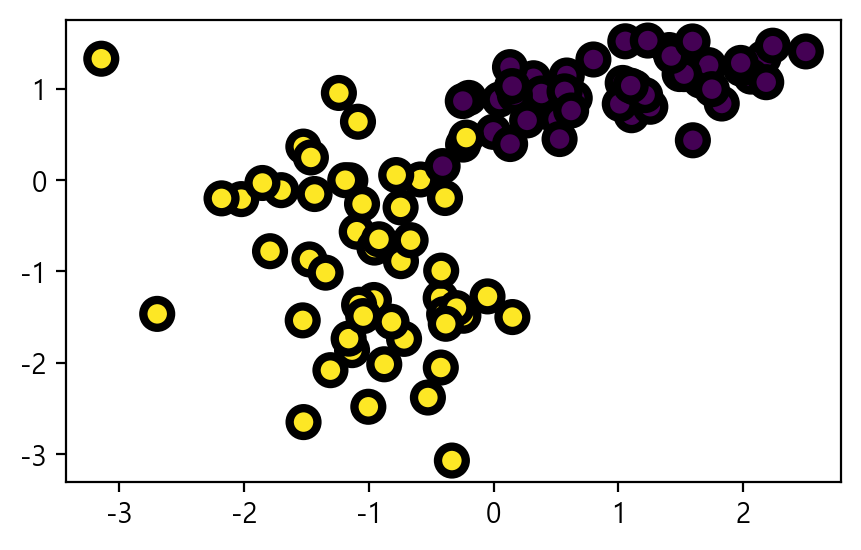

In [12]:
plt.figure(figsize=(5,3))
plt.scatter(x=X[:,0], y=X[:,1], c=y, s=100, edgecolors='k', lw=3)
# c = color, s=size, edgecolors=외곽선색, lw = line width(외곽선 두께)
plt.show()

In [38]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 개수
              init='k-means++',  # 초기 중심을 서로 멀리 초기화(random)
              n_init=10,  # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
              max_iter=300  # 각 실행에서 300번 반복하여 중심 옮기기 
              )
model.fit(X)

KMeans(n_clusters=2, n_init=10)

In [39]:
c0, c1 = model.cluster_centers_  # 모델이 정한 두 중심점
c0, c1

(array([-1.04309294, -0.91306043]), array([1.04081788, 1.01099376]))

In [40]:
print('modelLabel : ', model.labels_)
pred = model.predict(X)
print('예측값 : ', model.predict(X))
print('실제값 : ', y)

modelLabel :  [1 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 1 1 0 1 0
 1 0 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 0 0 1 0]
예측값 :  [1 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 1 1 0 1 0
 1 0 0 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 0 0 1 0]
실제값 :  [0 1 0 1 0 1 1 0 1 1 1 1 0 0 0 0 0 1 1 0 0 1 0 1 0 1 0 1 1 1 1 0 1 1 1 1 1
 1 1 1 1 0 1 1 0 0 0 0 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 1 0 1
 0 1 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 0 1]


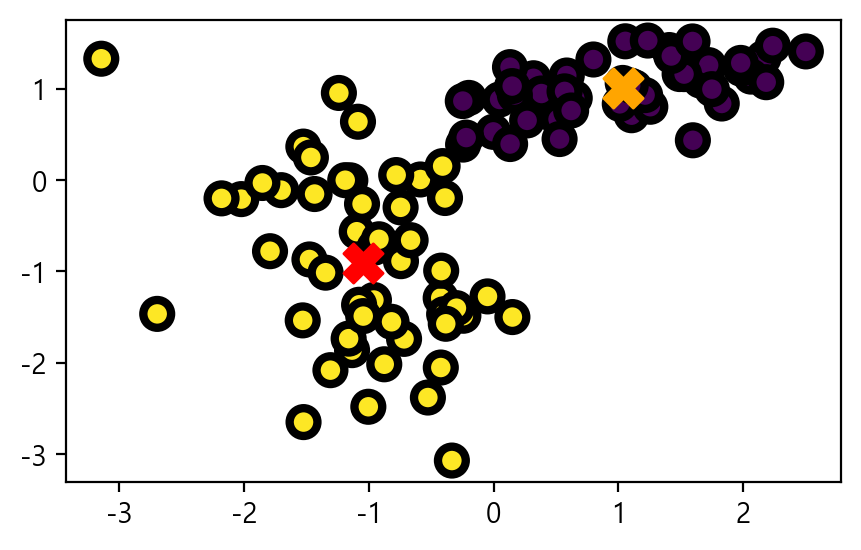

In [30]:
plt.figure(figsize=(5,3))
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3)
# c = color, s=size, edgecolors=외곽선색, lw = line width(외곽선 두께)
plt.scatter(x=c0[0], y=c0[1], s=200, c='orange', marker='X')
plt.scatter(x=c1[0], y=c1[1], s=200, c='r', marker='X')
plt.show()

### cf.Normalizer 적용

In [32]:
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xn = scaler.fit_transform(X)
Xn[:5]

array([[ 0.27564659,  0.96125905],
       [-0.86214709,  0.50665807],
       [ 0.88613252,  0.46343193],
       [-0.10827847, -0.9941206 ],
       [ 0.69726733,  0.71681118]])

In [34]:
print(np.c_[X, Xn][:5])

[[ 0.31968135  1.11482094  0.27564659  0.96125905]
 [-1.08712913  0.63887329 -0.86214709  0.50665807]
 [ 2.15276789  1.12586026  0.88613252  0.46343193]
 [-0.33450646 -3.07115329 -0.10827847 -0.9941206 ]
 [ 1.03464777  1.06364811  0.69726733  0.71681118]]


In [48]:
modeln = KMeans(n_clusters=2, # 군의 개수
              init='k-means++',  # 초기 중심을 서로 멀리 초기화(random)
              n_init=10,  # 각 다른 초기값을 10번 실행해보고 가장 좋은 모델 선택
              max_iter=300  # 각 실행에서 300번 반복하여 중심 옮기기 
              )
modeln.fit(Xn)
predn = modeln.predict(Xn)
d0, d1 = modeln.cluster_centers_  

In [49]:
modeln.labels_

array([0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1])

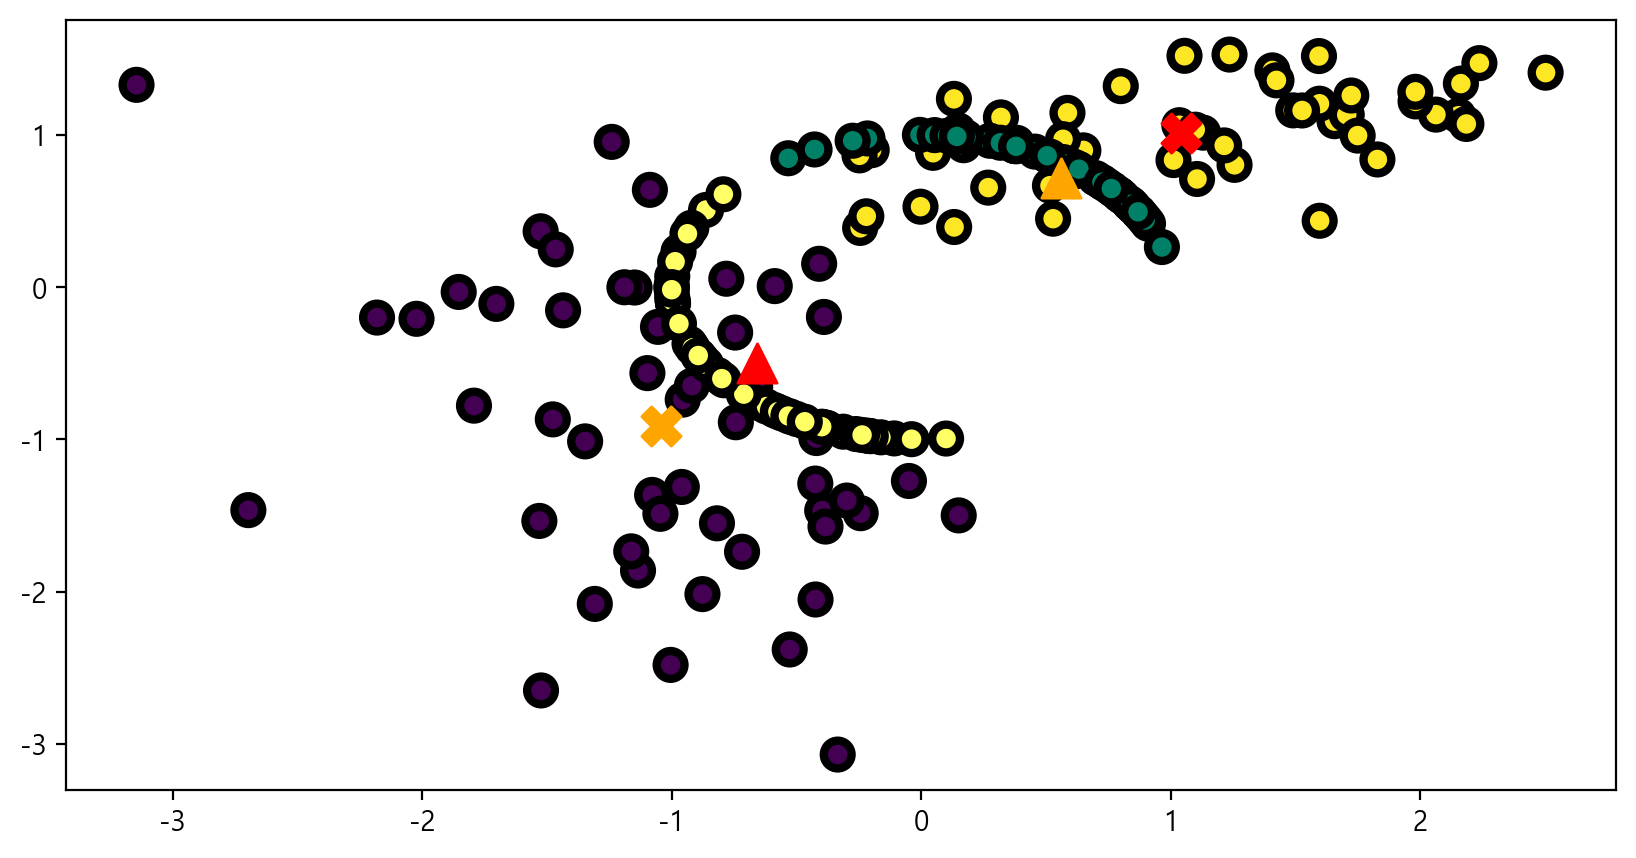

In [54]:
plt.figure(figsize=(10,5))
plt.scatter(x=X[:,0], y=X[:,1], c=pred, s=100, edgecolors='k', lw=3)
# c = color, s=size, edgecolors=외곽선색, lw = line width(외곽선 두께)
plt.scatter(x=c0[0], y=c0[1], s=200, c='orange', marker='X')
plt.scatter(x=c1[0], y=c1[1], s=200, c='r', marker='X')

plt.scatter(x=Xn[:,0], y=Xn[:,1], c=predn, s=100, edgecolors='k', lw=3, cmap='summer')
# c = color, s=size, edgecolors=외곽선색, lw = line width(외곽선 두께)
plt.scatter(x=d0[0], y=d0[1], s=200, c='orange', marker='^')
plt.scatter(x=d1[0], y=d1[1], s=200, c='r', marker='^')
plt.show()

### K-means 클러스터링의 한계점
- 군의 특성이 다를경우
    - 군의 크기, 밀도, 비구형
- 이상치를 포함할 경우 : 이상치를 조정/삭제한 후 클러스터링

In [56]:
import numpy as np
np.random.seed(0)
# group0 => avg -10, std 2, row 10, col 2 data
group0 = np.random.normal(loc=-10, scale=2, size=(10,2))
y = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y]

# group1 => avg 10, std 2, row 10, col 2 data
group1 = np.random.normal(loc=10, scale=2, size=(10,2))
y = np.full(group1.shape[0], 1)
group1 = np.c_[group1, y]

# group2 => avg 0, std 5, row 100, col 2 data
group2 = np.random.normal(loc=0, scale=5, size=(100,2))
y = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y]

In [58]:
group0[:3], group1[:3], group2[:3]

(array([[ -6.47189531,  -9.19968558,   0.        ],
        [ -8.04252403,  -5.5182136 ,   0.        ],
        [ -6.26488402, -11.95455576,   0.        ]]),
 array([[ 4.89402037, 11.30723719,  1.        ],
        [11.7288724 ,  8.51566996,  1.        ],
        [14.53950925,  7.09126865,  1.        ]]),
 array([[-5.24276483, -7.10008969,  2.        ],
        [-8.53135095,  9.75387698,  2.        ],
        [-2.54826091, -2.19037151,  2.        ]]))

In [59]:
data = np.r_[group0, group1, group2]
data[::10], data.shape

(array([[-6.47189531, -9.19968558,  0.        ],
        [ 4.89402037, 11.30723719,  1.        ],
        [-5.24276483, -7.10008969,  2.        ],
        [-3.36230224, -1.79776581,  2.        ],
        [-5.8257492 ,  4.50413243,  2.        ],
        [ 9.41575349, -6.73879531,  2.        ],
        [ 1.88212766, -5.49700395,  2.        ],
        [-7.45628796,  2.19695851,  2.        ],
        [-2.49016225,  9.64766027,  2.        ],
        [-1.76996956, -6.87475647,  2.        ],
        [-1.84590919, -1.19689589,  2.        ],
        [-4.779725  , -1.72990888,  2.        ]]),
 (120, 3))

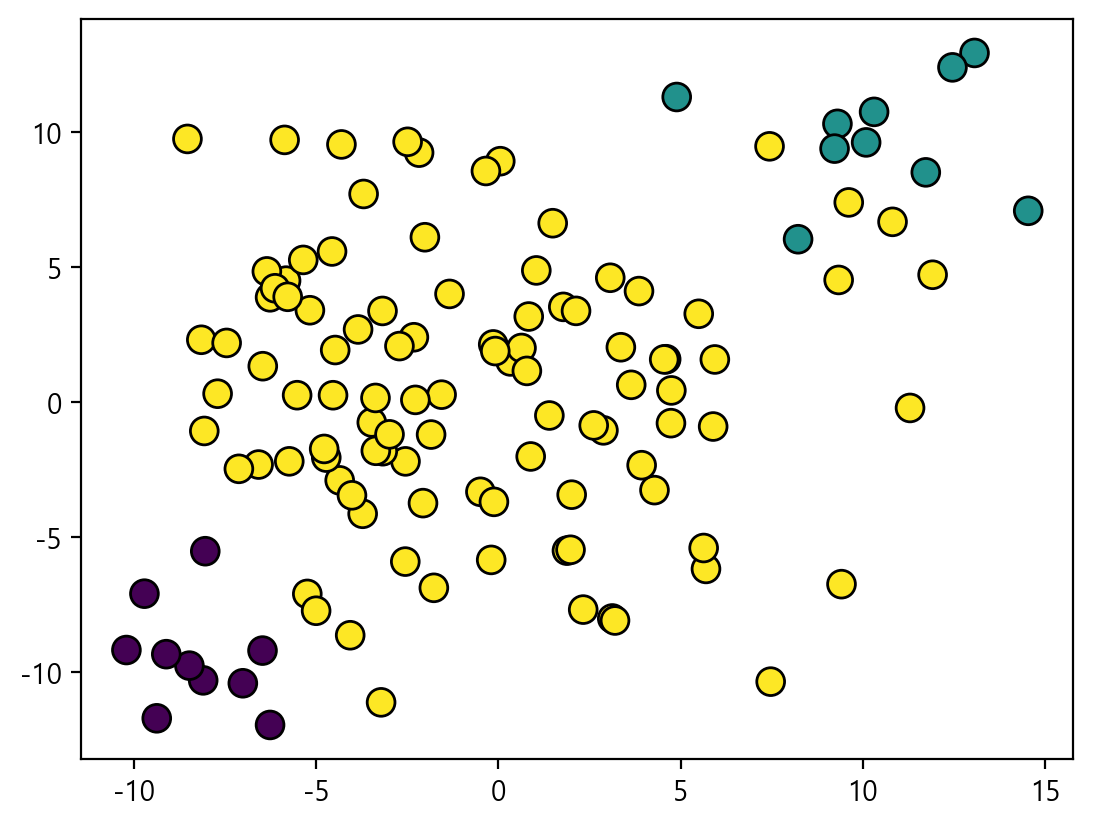

In [60]:
plt.scatter(x=data[:,0], y=data[:,1], c=data[:,2], s=100, edgecolors='k')
plt.show()

In [67]:
model = KMeans(n_clusters=3,
              init='k-means++',
              n_init=4,
              max_iter=300)
model.fit(data[:,:2])

KMeans(n_clusters=3, n_init=4)

In [68]:
model.cluster_centers_

array([[-3.23795138,  3.79797742],
       [ 7.93234415,  5.526175  ],
       [-2.11638402, -5.40013046]])

In [70]:
pred = model.predict(data[:,:2])
pred = model.labels_

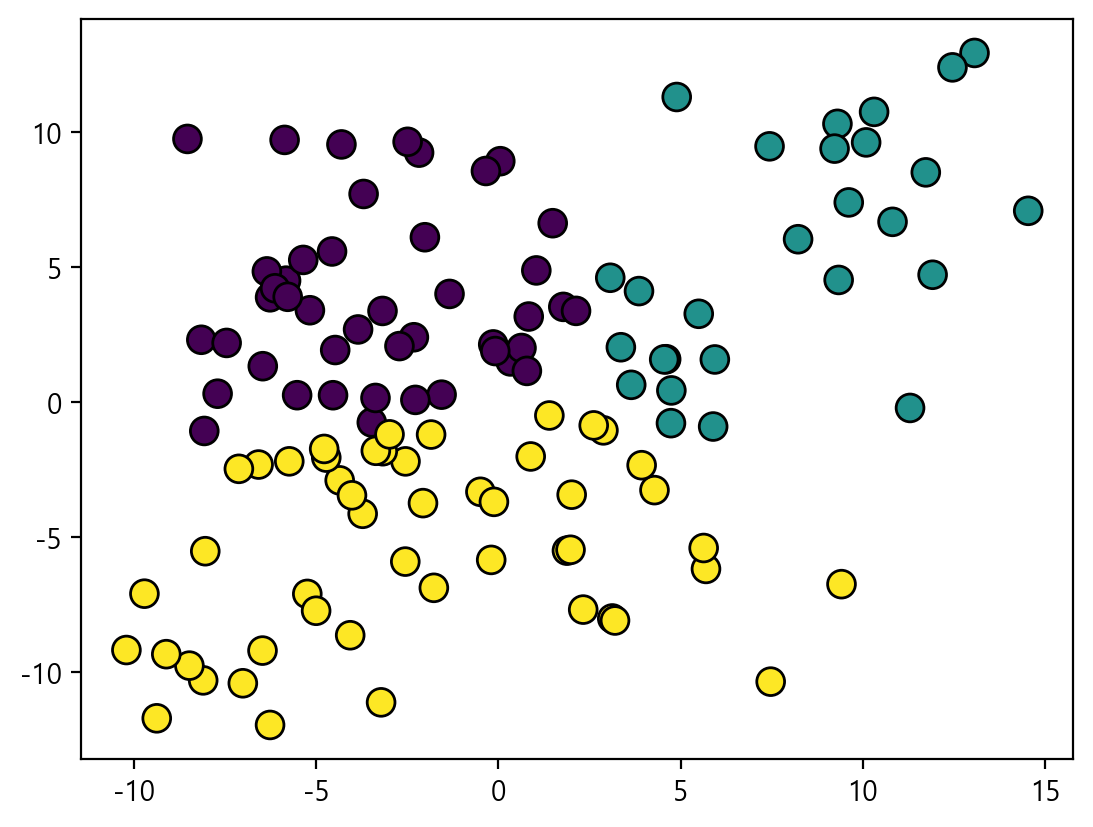

In [71]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.show()

In [72]:
model = KMeans(n_clusters=6, init='k-means++', n_init=10)
model.fit(data[:,:2])

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=6)

In [73]:
c= model.cluster_centers_
pred = model.labels_
pred

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 2,
       4, 2, 4, 4, 1, 3, 3, 4, 4, 5, 1, 4, 4, 3, 1, 1, 4, 4, 2, 1, 0, 3,
       2, 2, 3, 3, 2, 3, 1, 2, 2, 4, 0, 0, 2, 2, 3, 3, 1, 3, 4, 2, 3, 4,
       4, 2, 3, 1, 4, 3, 0, 2, 4, 2, 4, 1, 1, 4, 2, 3, 2, 5, 3, 3, 1, 2,
       4, 4, 1, 5, 1, 4, 2, 4, 1, 3, 3, 0, 4, 3, 1, 1, 3, 3, 1, 4, 3, 3,
       4, 4, 4, 3, 4, 4, 4, 2, 1, 3])

C:\Users\Admin\AppData\Local\Temp\ipykernel_29168\3577752429.py:2: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=c[:,0], y=c[:,1], c='r', s=200, marker='x', edgecolors='k', lw=3)


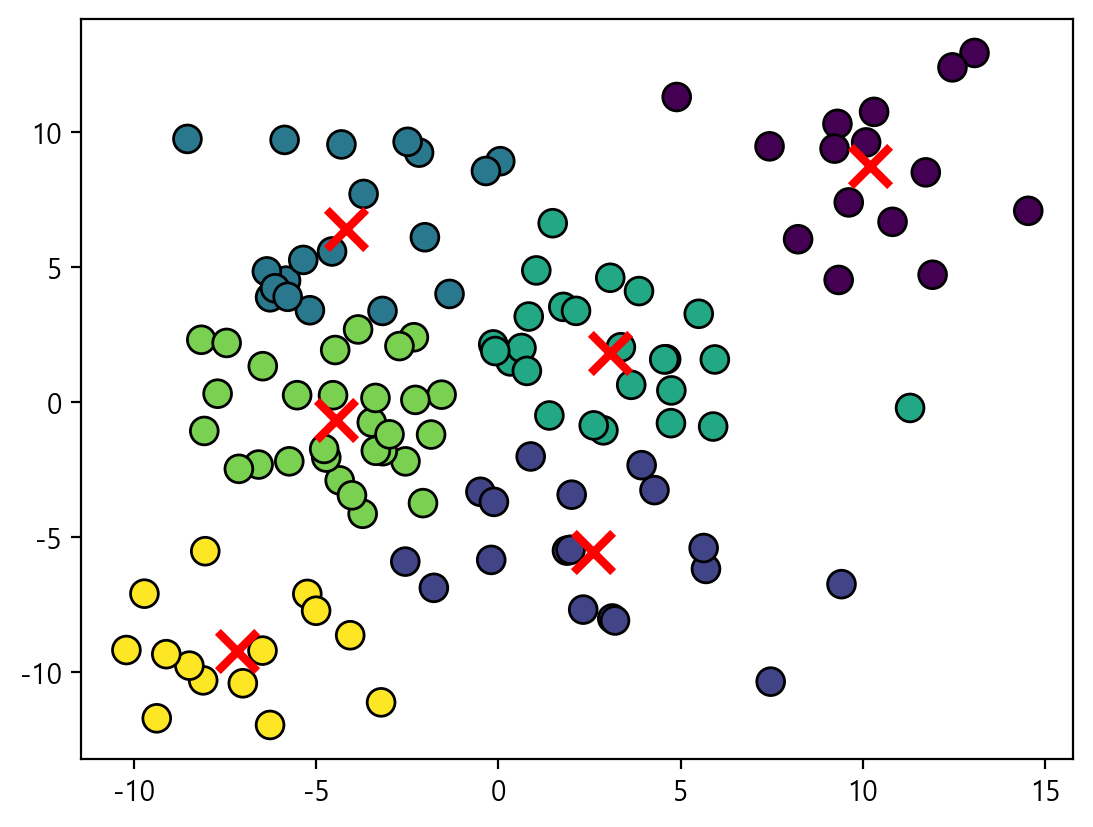

In [75]:
plt.scatter(x=data[:,0], y=data[:,1], c=pred, s=100, edgecolors='k')
plt.scatter(x=c[:,0], y=c[:,1], c='r', s=200, marker='x', edgecolors='k', lw=3)
plt.show()

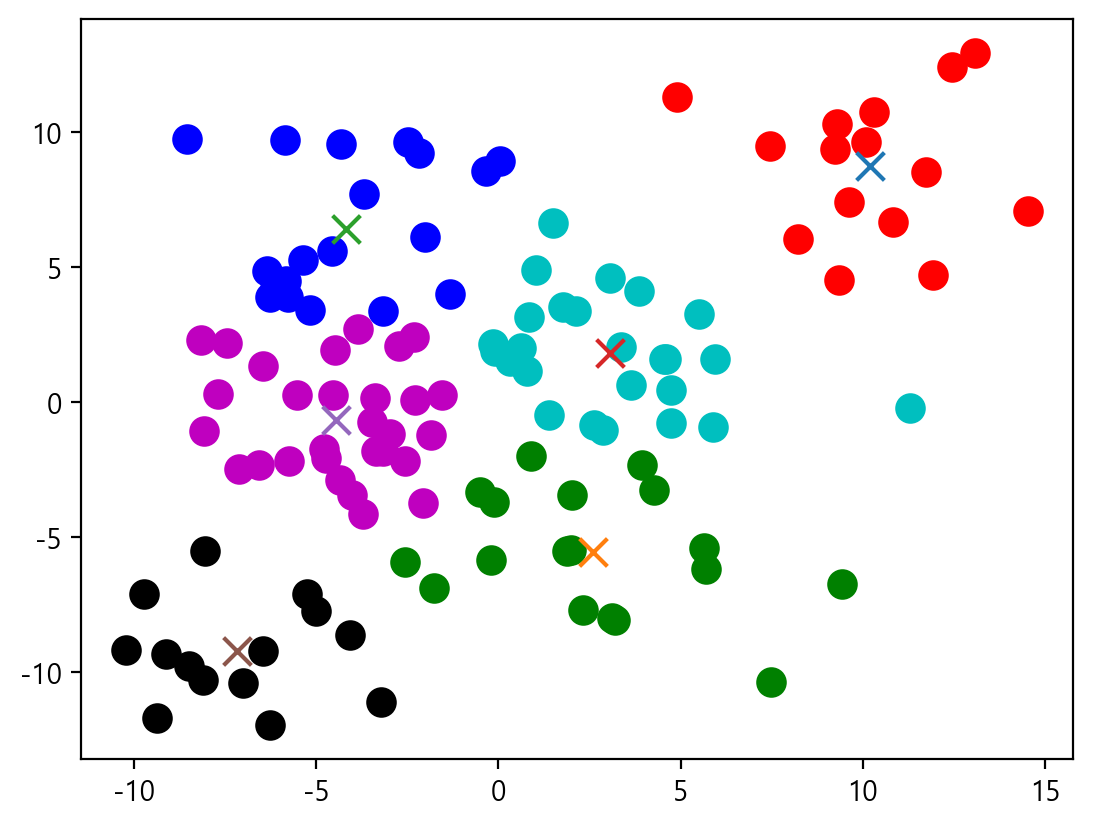

In [77]:
colors= ['r', 'g', 'b', 'c', 'm', 'k']
for i in range(len(c)):
    plt.scatter(x=data[pred==i, 0], y=data[pred==i, 1], c=colors[i], s=100)
    plt.scatter(x=c[i, 0], y=c[i, 1], marker='x', s=100)

# 3절. Hierarchical 클러스터링
- 군끼리 묶으면서 최종적으로 하나의 군집이 될때까지 묶는 클러스터링
- 군집의 수를 미리 정해주지 않음
- 군집간의 거리 기반으로 클러스터링

In [85]:
import seaborn as sns
iris = sns.load_dataset('iris')

# 계층적 군집을 위한 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(iris.species)
iris['species'] = le.transform(iris.species)
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [86]:
from scipy.cluster.hierarchy import linkage
# method 거리계산을 어떻게 할지
# 'complete' 두 클러스터 사이에서 가장 먼 거리를 이용
# 'single' 두 클러스터 사이게서 가장 먼 거리를 이용
# 'average' 두 클러스터 내의 각 점에서 다른 클러스터의 모든 점의 평균거리 이용
cluster_model = linkage(iris, method='complete')

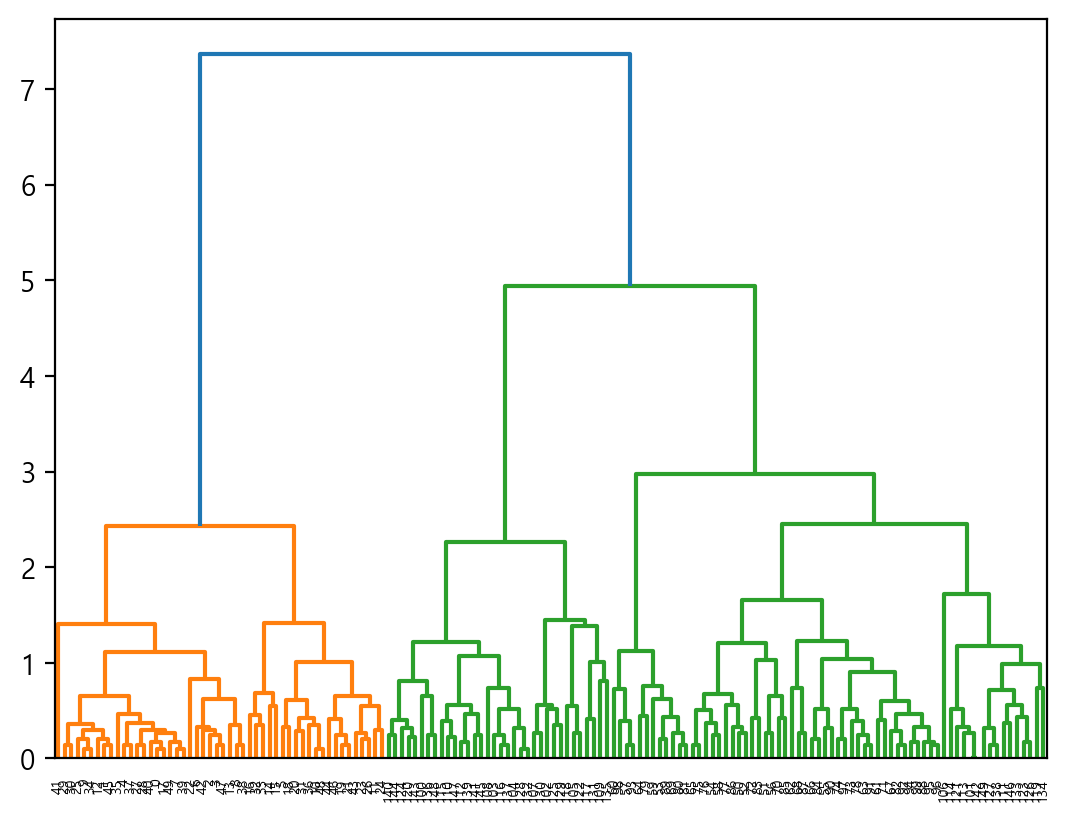

In [87]:
from scipy.cluster.hierarchy import dendrogram
dendrogram(cluster_model, labels=iris.index)
plt.show()

In [88]:
from scipy.cluster.hierarchy import fcluster # 군집화
fcluster(cluster_model,
        t=4, # dendrogram의 y축의 값
        criterion='distance')  # 군집화 기준
# crirerion = 'distance'일 때 t 값은 dendrogram  y축의 값

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [ ]:
fcluster(cluster_model,
        t=3,
        criterion='maxclust')
# criterion='maxclust' 일때, t값은 클러스터의 갯수(군집화된 그룹 개수)

In [94]:
fcluster(cluster_model,
        t=5,
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

# 4절. DBSCAN 클러스터링
- 연결기반(밀도기반) 군집화 알고리즘(이상치를 자동감지)
- 단점 : 클러스터의 밀도가 일정치 않으면 성능하락

array([[1.05686424, 0.82659809, 0.        ],
       [2.6592517 , 0.2853955 , 0.        ],
       [0.53202253, 0.29174685, 0.        ],
       [0.67335488, 0.78925236, 0.        ],
       [0.13151636, 0.35642998, 0.        ]])

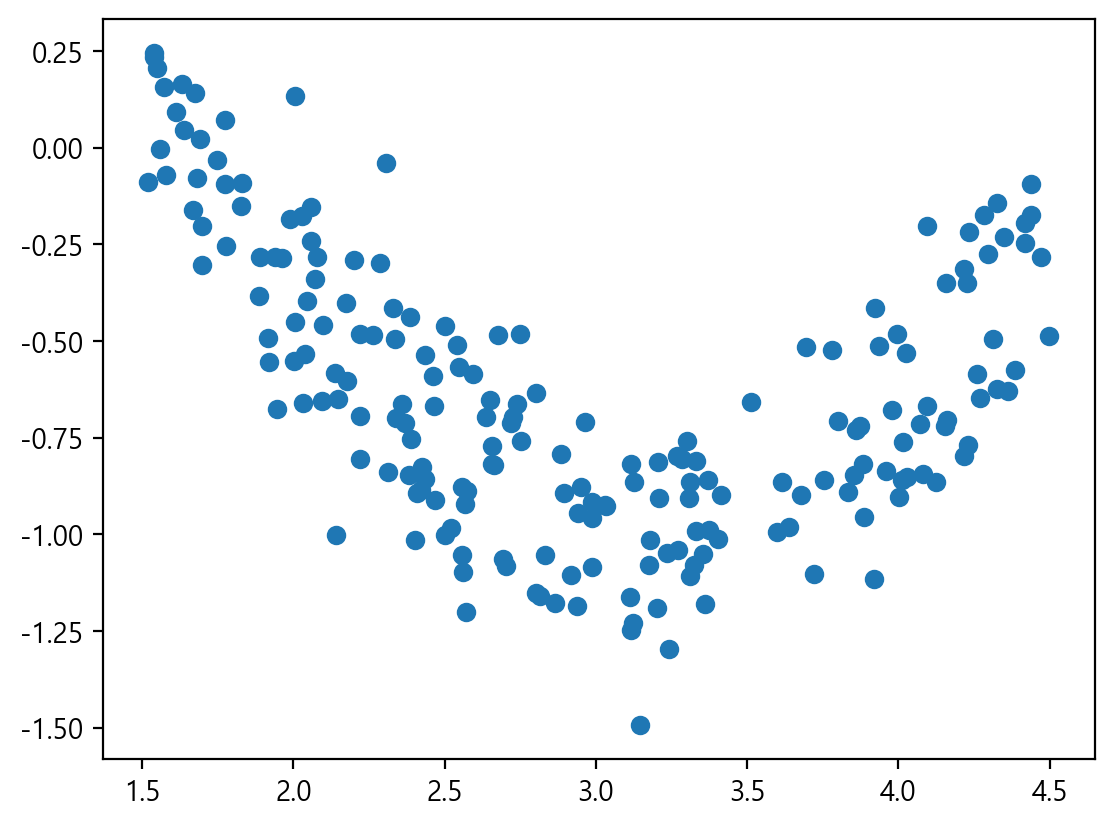

In [106]:
X1 = np.random.rand(200)*3  # 0이상 3 미만의 실수 난수 200개
noise = np.random.normal(0, 0.2, 200)
Y1 = np.sin(X1) + noise
# plt.scatter(X1, Y1) 
group1 = np.c_[X1, Y1, np.full(200, 0) ]
group1

X2 = X1 + 1.5  
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.full(200, 1) ]

plt.scatter(X2, Y2) 
group2
data = np.r_[group1, group2]
data[:5]

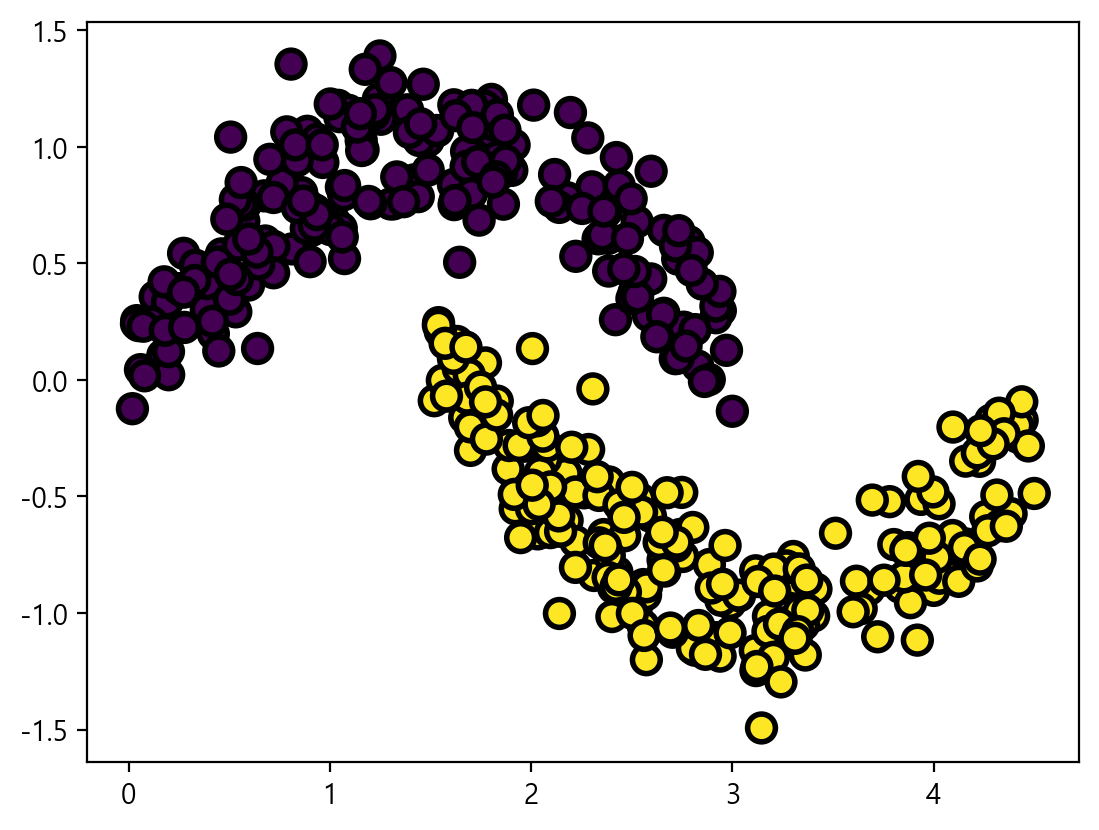

In [107]:
plt.scatter(data[:, 0], data[:, 1], c= data[:, 2], s=100, edgecolors='k', lw=2) 

In [120]:
from sklearn.cluster import DBSCAN
# 반경 0.3 이내에 최소
db = DBSCAN(eps=0.3, min_samples=10)
db.fit(data[:,:2])

DBSCAN(eps=0.3, min_samples=10)

In [121]:
labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0) # 클러스터수
n_noise_ = list(labels).count(-1)
print(f'이상치를 제외한 클러스터수 : {n_clusters_}, 이상치 갯수 : {n_noise_}')

이상치를 제외한 클러스터수 : 2, 이상치 갯수 : 0


# 5절. 모형 성능평가
- score 메소드를 통해 예측 모형 평가 (분류, 회귀에 해당. 군집에서는 사용X)
- metrics 모듈의 메소드를 통해 군집 모형 평가
## 5.1 metrics 함수이용
- 클러스터의 소속과 갯수를 모두 알고 있을 경우 평가

In [122]:
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
103,6.3,2.9,5.6,1.8,2


In [123]:
iris_X = iris.iloc[:,:-1]
iris_y = iris.iloc[:, -1]
iris_X.shape, iris_y.shape
iris_model3 = KMeans(n_clusters=3, n_init=10, random_state=1)
iris_model3.fit(iris_X)

KMeans(n_clusters=3, n_init=10, random_state=1)

In [124]:
pred = iris_model3.labels_
pred = iris_model3.predict(iris_X)
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [125]:
# pred 조정을 위해 : np.choose(배열시퀀스, 배열)
np.choose([3,2,2,3], [0, 10, 20, 30])

array([30, 20, 20, 30])

In [126]:
pred3 = np.choose(iris_model3.labels_, [1,0,2])
pred3 # 조정된 예측값

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [127]:
# 3개 cluster로 군집화한 자료
print('실제값 :', iris_y[::50])
print('예측값 :', pred3[::50])

실제값 : 0      0
50     1
100    2
Name: species, dtype: int32
예측값 : [0 1 2]


In [128]:
iris_model2 = KMeans(n_clusters=2, n_init=10, random_state=1)
iris_model2.fit(iris_X)

KMeans(n_clusters=2, n_init=10, random_state=1)

In [130]:
pred2 = iris_model2.labels_
# 2개 cluster로 군집화한 자료
iris_y2 = np.array([0]*50 + [1]*100)
print('실제값 :', iris_y2)
print('예측값 :', pred2)

실제값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
예측값 : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [132]:
pred3 = iris_model3.labels_
pred3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [133]:
# 클러스터가 3개인 경우 평가
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labels_true=iris_y, # 실제값
                   labels_pred=pred3)  # 클러스터링 예측

0.7302382722834697

In [134]:
# 클러스터가 2개인 경우 평가
adjusted_rand_score(labels_true=iris_y2, # 실제값
                   labels_pred=pred2)  # 클러스터링 예측

0.920405050901892

In [139]:
from sklearn.metrics import mutual_info_score
mutual_info_score(iris_y, pred3)

0.8255910976103356

In [140]:
mutual_info_score(iris_y2, pred2)

0.5596576064224734

In [135]:
from sklearn.metrics import v_measure_score  
v_measure_score(iris_y, pred3)

0.7581756800057784

In [138]:
v_measure_score(iris_y2, pred2)  # 2개 그룹으로 군집화 하는 것이 좋은 성능

0.870385156563164

## 5.2 실루엣계수(Silhouette Coefficient)
- 클러스터 개수, 소속을 모르고 있을 경우 평가하는 방법


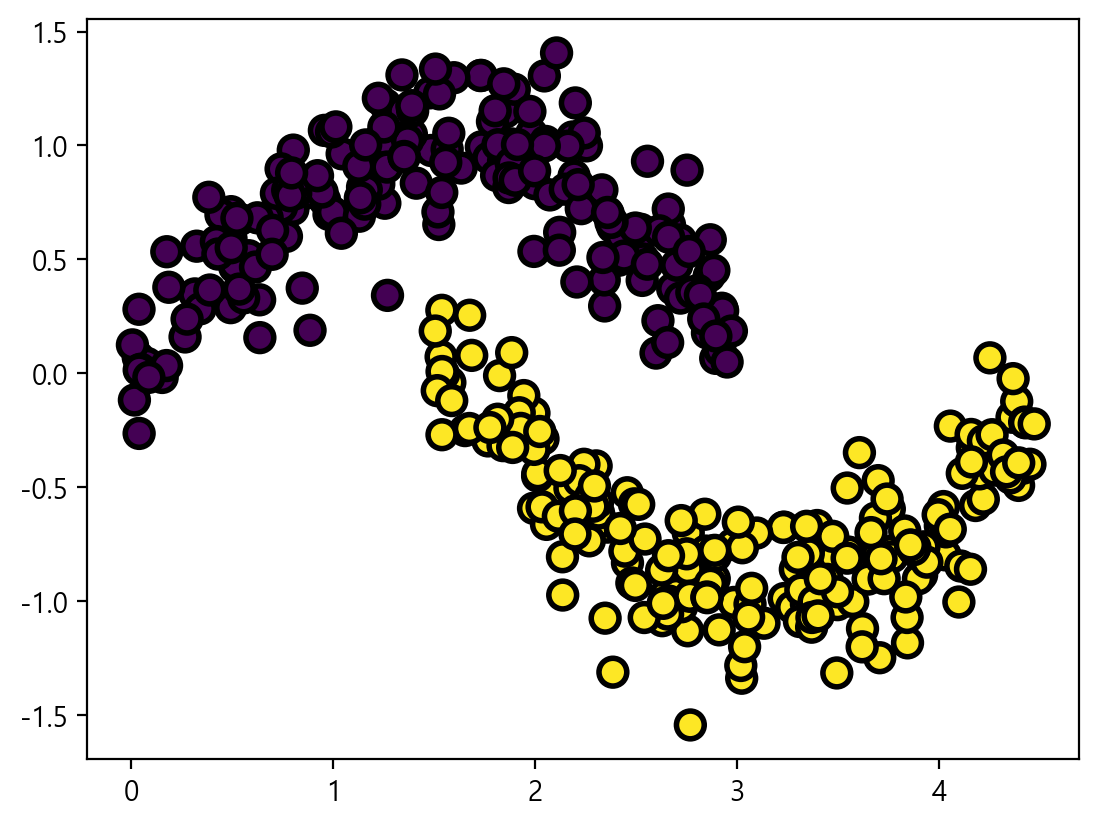

In [141]:
X1 = np.random.rand(200)*3  # 0이상 3 미만의 실수 난수 200개
noise = np.random.normal(0, 0.2, 200)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(200, 0) ]

X2 = X1 + 1.5  
Y2 = np.cos(X2) + noise
group2 = np.c_[X2, Y2, np.full(200, 1) ]

data = np.r_[group1, group2]

plt.scatter(data[:, 0], data[:, 1], c= data[:, 2], s=100, edgecolors='k', lw=2) 

In [143]:
from sklearn.metrics import silhouette_score
range_n_cluster = [2,3,4,5,6,7,8,9,10]
for n_clusters in range_n_cluster:
    # print(n_clusters)
    model = KMeans(n_clusters=n_clusters,
                  n_init=10,
                  random_state=2)
    model.fit(data[:,:2])
    score = silhouette_score(X=data[:,:2],    # 타겟변수는 모르므로 y값은 없음
                            labels=model.labels_)
    print('클러스트수 : {}, 실루엣 계수 : {}'.format(n_clusters, score))
    # 실루엑 셰수가 가장 높은 6개로 클러스터링 할 예정

클러스트수 : 2, 실루엣 계수 : 0.5254186194958246
클러스트수 : 3, 실루엣 계수 : 0.45964270572253546
클러스트수 : 4, 실루엣 계수 : 0.47264760056493416
클러스트수 : 5, 실루엣 계수 : 0.4792001616257931
클러스트수 : 6, 실루엣 계수 : 0.4918153096805722
클러스트수 : 7, 실루엣 계수 : 0.4821033846763062
클러스트수 : 8, 실루엣 계수 : 0.4752753305432114
클러스트수 : 9, 실루엣 계수 : 0.47551089348567294
클러스트수 : 10, 실루엣 계수 : 0.457719091512747


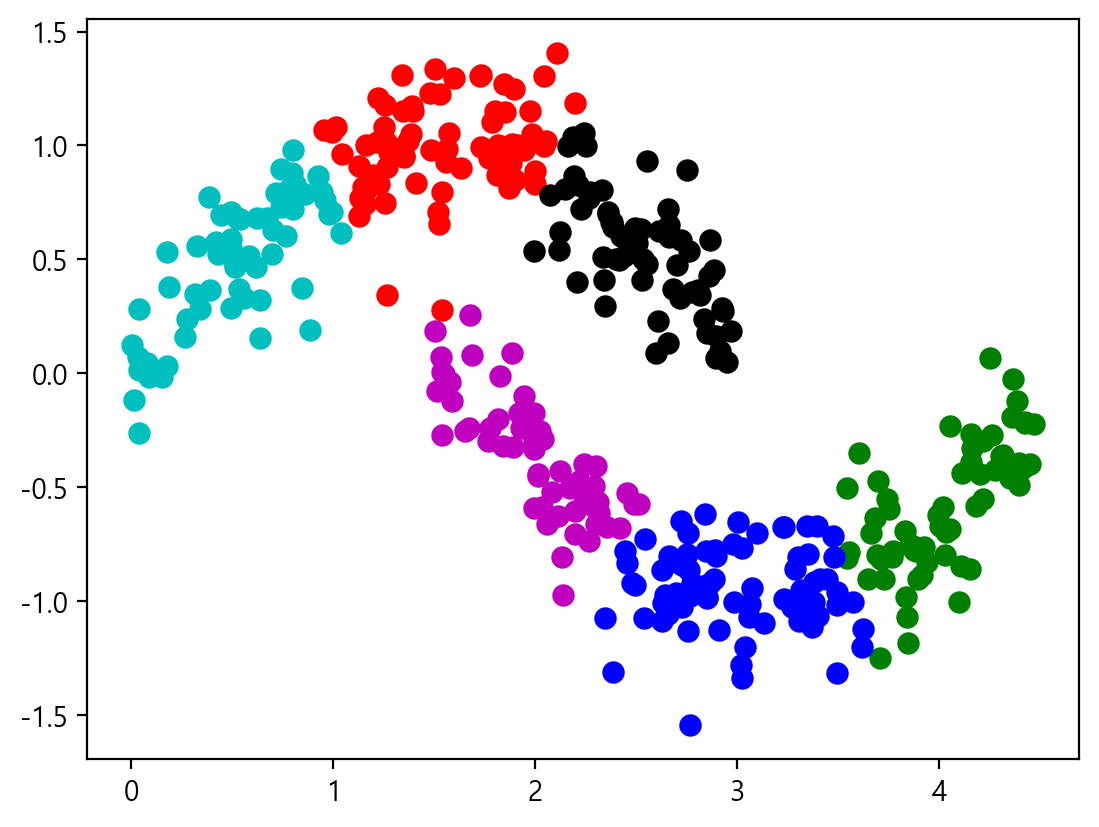

In [145]:
model = KMeans(n_clusters=6, n_init=10, init='k-means++')
model.fit(data[:,:-1])
c = model.cluster_centers_
colors= ['r', 'g', 'b', 'c', 'm', 'k']
for i in range(len(colors)):
    plt.scatter(data[model.labels_==i, 0],
               data[model.labels_==i, 1],
               c=colors[i], s=50)
    